# Phase 4 — Real-event change detection and temporal analysis

This notebook screens candidate Canadian flood events, selects a reproducible case, and tests whether RCM can **detect, map, and monitor** real water-extent change while preserving the Phase 3 safeguards. The selected case is the **December 2025 Fraser Valley / Lower Fraser flood**, using a compact Chilliwack-area AOI.

The analysis is intentionally conservative: the official NRCan Emergency Geomatics Service (EGS) RCM-derived flood classes drive the event sequence; public CEOS-ARD observations independently bracket the event; Sentinel-2 supplies an optical recovery-period check; and OpenStreetMap roads provide an initial exposure overlay. Infrastructure intersections are not claims of damage.

## 1. Purpose

In [22]:
from __future__ import annotations

from collections import deque
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen, urlretrieve
from zipfile import ZipFile
import json
import tempfile
import xml.etree.ElementTree as ET
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import rasterio
from IPython.display import Markdown, display
from pyproj import Transformer
from pystac_client import Client
from rasterio.features import geometry_mask, rasterize, shapes
from rasterio.transform import array_bounds, from_origin
from rasterio.warp import Resampling, reproject, transform_geom
from rasterio.windows import Window, from_bounds
from shapely.geometry import LineString, box, mapping, shape
from shapely.ops import transform as shapely_transform, unary_union

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
warnings.filterwarnings("ignore", message="Could not parse bucket/account from href.*", category=UserWarning)

RCM_STAC = "https://www.eodms-sgdot.nrcan-rncan.gc.ca/search"
EARTH_SEARCH = "https://earth-search.aws.element84.com/v1"
EGS_BASE = "https://data.eodms-sgdot.nrcan-rncan.gc.ca/public/EGS/2025/Flood/CAN/BC"
WORKING_CRS = "EPSG:32610"
AOI_BOUNDS_UTM = (563960, 5443240, 569960, 5449240)
to_wgs84 = Transformer.from_crs(WORKING_CRS, "EPSG:4326", always_xy=True).transform
AOI_WGS84 = shapely_transform(to_wgs84, box(*AOI_BOUNDS_UTM))
AOI_BBOX = AOI_WGS84.bounds

RR_THRESHOLD_DB = -17.314
GRID_METRES = 1000
CONTROL_CV_PCT = 3.20
CONTROL_MAX_DEVIATION_PCT = 5.88
CONTROL_S2_AREA_DIFFERENCE_PCT = 4.88
PIXEL_SIZE = 20
PIXEL_AREA_HA = PIXEL_SIZE * PIXEL_SIZE / 10_000

print("Working CRS:", WORKING_CRS)
print("AOI WGS84 bounds:", tuple(round(value, 6) for value in AOI_BBOX))
print("Fixed analysis pixel:", f"{PIXEL_SIZE} m × {PIXEL_SIZE} m")

Working CRS: EPSG:32610
AOI WGS84 bounds: (-122.123101, 49.138003, -122.039809, 49.192623)
Fixed analysis pixel: 20 m × 20 m


## 2. Phase 3 constraints inherited

- CEOS-ARD validity means `data_mask == 1`; all other codes remain unknown.
- Platform, orbit, mode, polarization, CRS, resolution, transform, local incidence angle, and gamma/sigma ratio remain visible diagnostics.
- The fixed `RR < -17.314 dB` rule is used only for the same CEOS-ARD radiometric representation as Phase 3. It is **not** transferred to the EGS vector product or Level-1 GRD.
- Continuous ARD layers are bilinearly reprojected to the fixed 20 m working grid. Categorical masks use nearest-neighbour; categorical optical results use mode aggregation.
- Phase 2 values (CV 3.20%, maximum deviation 5.88%, and same-day RCM/Sentinel area difference 4.88%) are empirical feasibility benchmarks, not universal confidence limits.

## 3. Candidate-event definition

In [23]:
candidate_table = pd.DataFrame([
    {
        "candidate": "Nova Scotia flood, 21–23 Jul 2023",
        "official impact evidence": "Extreme rainfall; public-safety and road/bridge impacts",
        "RCM feasibility": "Rejected: no intersecting public RCM-ARD or Level-1 records in the tested impact AOIs/window",
        "independent support": "Official reports available",
        "decision": "Reject — event-period RCM chain absent",
    },
    {
        "candidate": "Central Ottawa River spring freshet, May 2025",
        "official impact evidence": "Official flood products and water-level reporting",
        "RCM feasibility": "RCM1 same-platform/orbit sequence available",
        "independent support": "NRCan May 2/14 flood polygons",
        "decision": "Reject — no grid rose above 5.88 pp contextual comparison; RCM gain vs reference IoU = 0",
    },
    {
        "candidate": "Fraser Valley / Lower Fraser flood, Dec 2025",
        "official impact evidence": "Flood warning, evacuations, road closures, property impacts",
        "RCM feasibility": "Seven open EGS RCM products + public CEOS-ARD before/after brackets",
        "independent support": "Sentinel-2 + official emergency reporting",
        "decision": "SELECT",
    },
])
display(candidate_table)

,candidate,official impact evidence,RCM feasibility,independent support,decision
0,"Nova Scotia flood, 21–23 Jul 2023",Extreme rainfall; public-safety and road/bridge impacts,Rejected: no intersecting public RCM-ARD or Level-1 records in the tested impact AOIs/...,Official reports available,Reject — event-period RCM chain absent
1,"Central Ottawa River spring freshet, May 2025",Official flood products and water-level reporting,RCM1 same-platform/orbit sequence available,NRCan May 2/14 flood polygons,Reject — no grid rose above 5.88 pp contextual comparison; RCM gain vs reference IoU = 0
2,"Fraser Valley / Lower Fraser flood, Dec 2025","Flood warning, evacuations, road closures, property impacts",Seven open EGS RCM products + public CEOS-ARD before/after brackets,Sentinel-2 + official emergency reporting,SELECT


## 4. Official event evidence

Official reporting establishes the event context, not pixel-level ground truth:

- [EmergencyInfoBC flood warning, updated 10 Dec 2025](https://www.emergencyinfobc.gov.bc.ca/event/floodwatch-fraservalley-09122025/) names the Sumas River and Lower Fraser tributaries including the Chilliwack River, plus Abbotsford, Chilliwack, and Hope.
- [City of Abbotsford, 23 Dec 2025](https://www.abbotsford.ca/council/your-council-community/blog/abbotsford-shows-resilience-and-compassion-face-disaster) reports evacuation orders/alerts, property impacts, livestock loss, and a Highway 1 closure elsewhere in the wider event area.
- [B.C. road update, 13 Dec 2025](https://news.gov.bc.ca/releases/2025TT0126-001250) documents floodwater affecting Highway 1 in the wider Sumas area.
- [Fraser Valley Regional District update, 20 Dec 2025](https://www.fvrd.ca/EN/meta/news/news-archives/2025/atmospheric-river-update-saturday-dec-20.html?media=contrast) describes saturated conditions and declining Chilliwack River levels.

In [24]:
official_timeline = pd.DataFrame([
    ["2025-12-09 to 10", "Fraser Valley East watch upgraded to warning", "EmergencyInfoBC / BC River Forecast Centre"],
    ["2025-12-10 to 11", "Flood response, evacuation and road impacts reported across Fraser Valley", "Provincial and local authorities"],
    ["2025-12-12 14:08 UTC", "First selected Lower Fraser EGS RCM flood product", "NRCan EGS"],
    ["2025-12-13", "Floodwater reported on Highway 1 in the wider Sumas event area", "Province of British Columbia"],
    ["2025-12-14 to 21", "Six further Lower Fraser EGS observations track recession/recovery", "NRCan EGS"],
    ["2025-12-20", "FVRD reports saturated conditions and declining Chilliwack River levels", "Fraser Valley Regional District"],
    ["2025-12-23", "Abbotsford summarizes evacuations and infrastructure/community impacts", "City of Abbotsford"],
], columns=["date / time", "event evidence", "source"])
display(official_timeline)

,date / time,event evidence,source
0,2025-12-09 to 10,Fraser Valley East watch upgraded to warning,EmergencyInfoBC / BC River Forecast Centre
1,2025-12-10 to 11,"Flood response, evacuation and road impacts reported across Fraser Valley",Provincial and local authorities
2,2025-12-12 14:08 UTC,First selected Lower Fraser EGS RCM flood product,NRCan EGS
3,2025-12-13,Floodwater reported on Highway 1 in the wider Sumas event area,Province of British Columbia
4,2025-12-14 to 21,Six further Lower Fraser EGS observations track recession/recovery,NRCan EGS
5,2025-12-20,FVRD reports saturated conditions and declining Chilliwack River levels,Fraser Valley Regional District
6,2025-12-23,Abbotsford summarizes evacuations and infrastructure/community impacts,City of Abbotsford


## 5. Event AOI selection

The fixed 6 km × 6 km UTM Zone 10N AOI was selected by intersecting all seven EGS footprints with both public CEOS-ARD bracket acquisitions, then choosing a compact, 20 m-aligned rectangle with complete EGS coverage. It lies in the Chilliwack-area Lower Fraser corridor. This is a reproducibility/coverage choice, not a claim that the AOI contains the event's worst impacts.

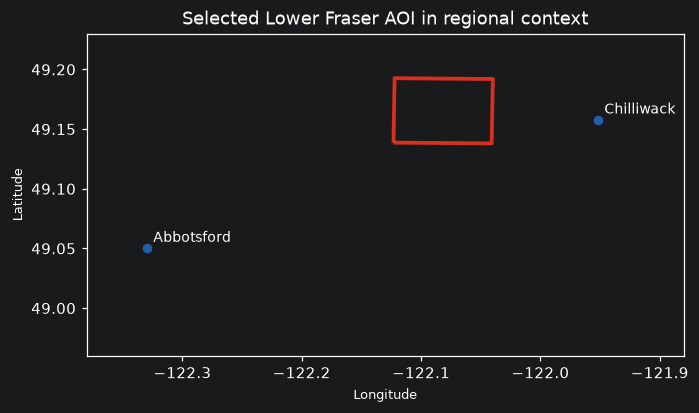

,working_bounds_utm10,wgs84_west,wgs84_south,wgs84_east,wgs84_north,nominal_area_km2
0,"(563960, 5443240, 569960, 5449240)",-122.123101,49.138003,-122.039809,49.192623,36.0


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
gpd.GeoSeries([AOI_WGS84], crs=4326).boundary.plot(ax=ax, linewidth=2.5, color="#d7301f")
places = pd.DataFrame({
    "place": ["Chilliwack", "Abbotsford", "Hope"],
    "lon": [-121.9515, -122.3295, -121.4417],
    "lat": [49.1579, 49.0504, 49.3829],
})
ax.scatter(places.lon, places.lat, color="#225ea8", s=28)
for row in places.itertuples():
    ax.annotate(row.place, (row.lon, row.lat), xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.set(xlim=(-122.38, -121.88), ylim=(48.96, 49.23), xlabel="Longitude", ylabel="Latitude",
       title="Selected Lower Fraser AOI in regional context")
ax.set_aspect("equal", adjustable="box")
plt.show()

display(pd.DataFrame([{
    "working_bounds_utm10": str(AOI_BOUNDS_UTM),
    "wgs84_west": AOI_BBOX[0], "wgs84_south": AOI_BBOX[1],
    "wgs84_east": AOI_BBOX[2], "wgs84_north": AOI_BBOX[3],
    "nominal_area_km2": 36.0,
}]).round(6))

## 6. RCM Level-1 / ARD coverage screening

In [26]:
rcm_screening = pd.DataFrame([
    ["2023 Nova Scotia candidate", "2023-06-15 to 2023-08-20", "RCMImageProducts + rcm-ard", 0,
     "No intersecting acquisitions in the tested official-impact AOIs; reject"],
    ["Selected event — Level-1", "2025-12-13 to 2025-12-23", "RCMImageProducts", 8,
     "Metadata visible; full ZIP requires EODMS bearer-token authentication"],
    ["Selected event — EGS", "2025-12-12 to 2025-12-21", "NRCan EGS RCM-derived vectors", 7,
     "Anonymous public ZIP download; selected main event sequence"],
    ["Selected event — public ARD", "2025-11-08 / 2026-01-07", "rcm-ard CEOS-ARD", 4,
     "Anonymous public COG ranges; two adjacent records mosaicked per date"],
], columns=["case / route", "window", "product", "records", "access / decision"])
display(rcm_screening)

,case / route,window,product,records,access / decision
0,2023 Nova Scotia candidate,2023-06-15 to 2023-08-20,RCMImageProducts + rcm-ard,0,No intersecting acquisitions in the tested official-impact AOIs; reject
1,Selected event — Level-1,2025-12-13 to 2025-12-23,RCMImageProducts,8,Metadata visible; full ZIP requires EODMS bearer-token authentication
2,Selected event — EGS,2025-12-12 to 2025-12-21,NRCan EGS RCM-derived vectors,7,Anonymous public ZIP download; selected main event sequence
3,Selected event — public ARD,2025-11-08 / 2026-01-07,rcm-ard CEOS-ARD,4,Anonymous public COG ranges; two adjacent records mosaicked per date


## 7. Sentinel-1 / Sentinel-2 coverage screening

In [27]:
earth = Client.open(EARTH_SEARCH)
s1_items = list(earth.search(
    collections=["sentinel-1-grd"], bbox=AOI_BBOX,
    datetime="2025-12-01T00:00:00Z/2025-12-28T23:59:59Z", max_items=None,
).items())
s2_items = list(earth.search(
    collections=["sentinel-2-c1-l2a"], bbox=AOI_BBOX,
    datetime="2025-12-01T00:00:00Z/2025-12-28T23:59:59Z", max_items=None,
).items())

support_screening = pd.DataFrame([
    ["Sentinel-1 GRD", len(s1_items), "IW VV/VH; 11 metadata records in tested window",
     "Level-1 measurement assets are requester-pays; not forced into quantitative analysis"],
    ["Sentinel-2 C1 L2A", len(s2_items), "B03 green, B08 NIR, SCL",
     "Public COGs; 2 Dec pre-event and 27 Dec recovery observations selected"],
    ["NRCan EGS flood extent", 7, "RCM-derived permanent-water and open-water-flood vector classes",
     "Public official products; main event sequence"],
])
support_screening.columns = ["source", "records", "relevant data", "access / use"]
display(support_screening)

,source,records,relevant data,access / use
0,Sentinel-1 GRD,11,IW VV/VH; 11 metadata records in tested window,Level-1 measurement assets are requester-pays; not forced into quantitative analysis
1,Sentinel-2 C1 L2A,14,"B03 green, B08 NIR, SCL",Public COGs; 2 Dec pre-event and 27 Dec recovery observations selected
2,NRCan EGS flood extent,7,RCM-derived permanent-water and open-water-flood vector classes,Public official products; main event sequence


## 8. Independent flood/event reference discovery

NRCan EGS products are authoritative operational products but are themselves RCM-derived, so they are not treated as an independent sensor validation of RCM. Sentinel-2 is the independent EO check; emergency reporting supplies historical/contextual validation; OSM supplies contextual infrastructure geometry.

In [28]:
reference_table = pd.DataFrame([
    ["Sentinel-2 L2A", "Independent optical water signal", "Earth Search STAC", "Open COG access"],
    ["EmergencyInfoBC / BC RFC", "Official event timing and affected-area context", "Government of B.C.", "Public web"],
    ["Local/provincial reports", "Evacuation and road-impact context", "Abbotsford / B.C. / FVRD", "Public web"],
    ["OpenStreetMap roads", "Preliminary infrastructure overlay", "OpenStreetMap contributors", "Overpass API; ODbL"],
], columns=["dataset", "role", "authority", "access"])
display(reference_table)

,dataset,role,authority,access
0,Sentinel-2 L2A,Independent optical water signal,Earth Search STAC,Open COG access
1,EmergencyInfoBC / BC RFC,Official event timing and affected-area context,Government of B.C.,Public web
2,Local/provincial reports,Evacuation and road-impact context,Abbotsford / B.C. / FVRD,Public web
3,OpenStreetMap roads,Preliminary infrastructure overlay,OpenStreetMap contributors,Overpass API; ODbL


## 9. Final case selection decision

**Decision:** select the December 2025 Fraser Valley / Lower Fraser flood, with a Chilliwack-area AOI. It is the first screened case with (1) a documented public-safety event, (2) multiple publicly downloadable RCM-derived event observations, (3) real public RCM observations bracketing the event, (4) independent optical support, and (5) infrastructure geometry. The July 2023 Nova Scotia preference was not forced after its tested AOIs failed RCM coverage screening.

In [29]:
selection_matrix = pd.DataFrame({
    "criterion": ["Documented event", "Pre RCM", "Event-near RCM", "Post RCM", "Independent EO/reference", "Infrastructure layer"],
    "result": ["Pass", "Pass — 8 Nov ARD", "Pass — 12–21 Dec EGS", "Pass — 7 Jan ARD", "Pass — Sentinel-2 + official reports", "Pass — OSM roads"],
})
display(selection_matrix)

,criterion,result
0,Documented event,Pass
1,Pre RCM,Pass — 8 Nov ARD
2,Event-near RCM,Pass — 12–21 Dec EGS
3,Post RCM,Pass — 7 Jan ARD
4,Independent EO/reference,Pass — Sentinel-2 + official reports
5,Infrastructure layer,Pass — OSM roads


## 10. Before / during / after acquisition selection

In [31]:
EGS_PRODUCTS = {
    "near-event": "Flood_CAN_BC_LowerFraser_20251212_140824.zip",
    "early-recession-1": "Flood_CAN_BC_LowerFraser_20251214_142423.zip",
    "early-recession-2": "Flood_CAN_BC_LowerFraser_20251215_015037.zip",
    "mid-recession-1": "Flood_CAN_BC_LowerFraser_20251216_140835.zip",
    "mid-recession-2": "Flood_CAN_BC_LowerFraser_20251217_141634.zip",
    "late-recession": "Flood_CAN_BC_LowerFraser_20251219_015014.zip",
    "recovery-period": "Flood_CAN_BC_LowerFraser_20251221_141646.zip",
}
S2_IDS = {
    "pre-event": "S2B_T10UEV_20251202T190649_L2A",
    "recovery-period": "S2C_T10UEV_20251227T191058_L2A",
}

CACHE_ROOT = Path(tempfile.gettempdir()) / "earth-in-motion-phase4-egs"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
egs_folders = {}
for label, filename in EGS_PRODUCTS.items():
    folder = CACHE_ROOT / filename.removesuffix(".zip")
    if not next(folder.glob("Flood_*.shp"), None):
        folder.mkdir(parents=True, exist_ok=True)
        archive = CACHE_ROOT / filename
        if not archive.exists():
            print("Downloading", filename)
            urlretrieve(f"{EGS_BASE}/{filename}", archive)
        with ZipFile(archive) as zipped:
            zipped.extractall(folder)
    egs_folders[label] = folder

acquisition_plan = pd.DataFrame([
    ["pre-event", "2025-11-08 01:42:39 UTC", "RCM3 public CEOS-ARD", "Actual RCM observation; Phase 3 fixed RR rule"],
    ["near-event", "2025-12-12 14:08:24 UTC", "RCM1 / NRCan EGS", "First selected event product; about two days after warning"],
    ["recovery sequence", "2025-12-14 to 2025-12-21", "RCM1/2/3 / NRCan EGS", "Six observations; not labelled as flood peak"],
    ["post-event", "2026-01-07 01:42:38 UTC", "RCM3 public CEOS-ARD", "Actual RCM observation on matching relative orbit"],
    ["optical recovery check", "2025-12-27 19:11:08 UTC", "Sentinel-2C L2A", "6.2 days after final EGS observation"],
], columns=["role", "timestamp / window", "source", "interpretation"])
display(acquisition_plan)

,role,timestamp / window,source,interpretation
0,pre-event,2025-11-08 01:42:39 UTC,RCM3 public CEOS-ARD,Actual RCM observation; Phase 3 fixed RR rule
1,near-event,2025-12-12 14:08:24 UTC,RCM1 / NRCan EGS,First selected event product; about two days after warning
2,recovery sequence,2025-12-14 to 2025-12-21,RCM1/2/3 / NRCan EGS,Six observations; not labelled as flood peak
3,post-event,2026-01-07 01:42:38 UTC,RCM3 public CEOS-ARD,Actual RCM observation on matching relative orbit
4,optical recovery check,2025-12-27 19:11:08 UTC,Sentinel-2C L2A,6.2 days after final EGS observation


## 11. RCM preprocessing for the selected event

The EGS vectors are categorical. They are clipped, reprojected, and rasterized directly to a fixed EPSG:32610 20 m grid using center-pixel semantics. Class 1 is permanent water and class 2 is open-water flood. EGS footprint polygons define validity. Public CEOS-ARD continuous RR/LIA/gamma-sigma layers are bilinearly reprojected; `data_mask` uses nearest-neighbour and only code 1 is accepted. Exact source transforms, CRS, resolution and platform metadata are retained below.

In [32]:
TARGET_TRANSFORM = from_origin(AOI_BOUNDS_UTM[0], AOI_BOUNDS_UTM[3], PIXEL_SIZE, PIXEL_SIZE)
TARGET_SHAPE = (
    int((AOI_BOUNDS_UTM[3] - AOI_BOUNDS_UTM[1]) / PIXEL_SIZE),
    int((AOI_BOUNDS_UTM[2] - AOI_BOUNDS_UTM[0]) / PIXEL_SIZE),
)
TARGET_BOUNDS = array_bounds(*TARGET_SHAPE, TARGET_TRANSFORM)
AOI_UTM = box(*AOI_BOUNDS_UTM)
AOI_MASK = geometry_mask([mapping(AOI_UTM)], out_shape=TARGET_SHAPE,
                         transform=TARGET_TRANSFORM, invert=True)

def rasterize_geometry(geometry, value=1):
    if geometry is None or geometry.is_empty:
        return np.zeros(TARGET_SHAPE, dtype=np.uint8)
    return rasterize(
        [(mapping(geometry), value)], out_shape=TARGET_SHAPE,
        transform=TARGET_TRANSFORM, fill=0, dtype=np.uint8,
        all_touched=False,
    )

def seeded_components(binary, seed):
    # Keep 8-connected candidate components that touch the fixed seed.
    rows, cols = binary.shape
    visited = np.zeros_like(binary, dtype=bool)
    selected = np.zeros_like(binary, dtype=bool)
    for start_row, start_col in np.argwhere(binary & seed):
        start_row, start_col = int(start_row), int(start_col)
        if visited[start_row, start_col]:
            continue
        queue = deque([(start_row, start_col)])
        visited[start_row, start_col] = True
        component = []
        while queue:
            row, col = queue.popleft()
            component.append((row, col))
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    if dr == dc == 0:
                        continue
                    rr, cc = row + dr, col + dc
                    if 0 <= rr < rows and 0 <= cc < cols and binary[rr, cc] and not visited[rr, cc]:
                        visited[rr, cc] = True
                        queue.append((rr, cc))
        for row, col in component:
            selected[row, col] = True
    return selected

def read_remote_window(item, key):
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif"):
        with rasterio.open(item.assets[key].href) as src:
            source_geom = transform_geom("EPSG:4326", src.crs, mapping(AOI_WGS84))
            requested = from_bounds(*shape(source_geom).bounds, transform=src.transform).round_offsets().round_lengths()
            try:
                window = requested.intersection(Window(0, 0, src.width, src.height))
            except rasterio.errors.WindowError:
                return None
            return {
                "array": src.read(1, window=window, masked=True),
                "transform": src.window_transform(window), "crs": str(src.crs),
                "nodata": src.nodata, "res": tuple(src.res),
                "source_transform": tuple(src.transform), "source_shape": (src.height, src.width),
            }

def project_asset(source, resampling, dst_nodata, dtype):
    destination = np.full(TARGET_SHAPE, dst_nodata, dtype=dtype)
    reproject(
        source=source["array"].filled(source["nodata"] if source["nodata"] is not None else dst_nodata),
        destination=destination, src_transform=source["transform"], src_crs=source["crs"],
        src_nodata=source["nodata"], dst_transform=TARGET_TRANSFORM, dst_crs=WORKING_CRS,
        dst_nodata=dst_nodata, resampling=resampling,
    )
    return destination

egs_scenes = {}
egs_rows = []
for label, folder in egs_folders.items():
    flood = gpd.read_file(next(folder.glob("Flood_*.shp"))).clip(AOI_WGS84).to_crs(WORKING_CRS)
    footprint = gpd.read_file(next(folder.glob("Footprint_*.shp"))).clip(AOI_WGS84).to_crs(WORKING_CRS)
    config = ET.parse(next(folder.glob("Config_*.xml"))).getroot()
    metadata = {child.tag: (child.text or "").strip() for child in config}
    permanent_geom = flood.loc[flood["class"].eq(1)].geometry.union_all()
    flood_geom = flood.loc[flood["class"].eq(2)].geometry.union_all()
    valid = rasterize_geometry(footprint.geometry.union_all()).astype(bool) & AOI_MASK
    permanent = rasterize_geometry(permanent_geom).astype(bool) & valid
    flood_mask = rasterize_geometry(flood_geom).astype(bool) & valid
    egs_scenes[label] = {"permanent": permanent, "flood": flood_mask, "valid": valid,
                         "metadata": metadata, "flood_gdf": flood, "footprint_gdf": footprint}
    egs_rows.append({
        "label": label, "datetime_utc": pd.Timestamp(f"{metadata['dateUTC']}T{metadata['timeUTC']}Z"),
        "platform": metadata["sensorName"], "beam": metadata["beam"],
        "polarization": metadata["polarization"], "orbit": metadata["orbitDirection"],
        "source_resolution_m": float(metadata["resolution"]), "source_crs": str(flood.crs),
        "confidence": metadata["confidenceLevelEN"], "valid_pixels": int(valid.sum()),
        "valid_pct": 100 * valid.sum() / AOI_MASK.sum(),
        "permanent_area_ha": permanent.sum() * PIXEL_AREA_HA,
        "flood_area_ha": flood_mask.sum() * PIXEL_AREA_HA,
    })

egs_df = pd.DataFrame(egs_rows).sort_values("datetime_utc").reset_index(drop=True)
all_egs_valid = np.logical_and.reduce([scene["valid"] for scene in egs_scenes.values()])
baseline = egs_scenes["near-event"]["permanent"] & all_egs_valid
water_masks = {label: baseline | (scene["flood"] & all_egs_valid) for label, scene in egs_scenes.items()}
pre_water = baseline
event_water = water_masks["near-event"]
post_water = water_masks["recovery-period"]
event_gain = all_egs_valid & ~pre_water & event_water
event_to_post_loss = all_egs_valid & event_water & ~post_water
event_to_post_gain = all_egs_valid & ~event_water & post_water

display(egs_df)
print(f"Common valid EGS cells: {all_egs_valid.sum():,} / {AOI_MASK.sum():,} ({all_egs_valid.mean()*100:.1f}%)")
print("Target transform:", TARGET_TRANSFORM)

,label,datetime_utc,platform,beam,polarization,orbit,source_resolution_m,source_crs,confidence,valid_pixels,valid_pct,permanent_area_ha,flood_area_ha
0,near-event,2025-12-12 14:08:24+00:00,RCM-1,5M22,HH-HV,DSC,5.0,EPSG:32610,Moderate,90000,100.0,971.88,54.92
1,early-recession-1,2025-12-14 14:24:23+00:00,RCM-1,16M9,HH-HV,DSC,16.0,EPSG:32610,Moderate,90000,100.0,971.88,20.60
2,early-recession-2,2025-12-15 01:50:37+00:00,RCM-3,SC30MB,HH-HV,ASC,30.0,EPSG:32610,Moderate,90000,100.0,971.88,50.72
3,mid-recession-1,2025-12-16 14:08:35+00:00,RCM-2,5M22,HH-HV,DSC,5.0,EPSG:32610,Moderate,90000,100.0,973.28,36.60
4,mid-recession-2,2025-12-17 14:16:34+00:00,RCM-2,16M16,HH-HV,DSC,16.0,EPSG:32610,Moderate,90000,100.0,973.28,37.28
5,late-recession,2025-12-19 01:50:14+00:00,RCM-1,SC30MB,HH-HV,ASC,30.0,EPSG:32610,Moderate,90000,100.0,973.28,28.96
6,recovery-period,2025-12-21 14:16:46+00:00,RCM-3,16M16,HH-HV,DSC,16.0,EPSG:32610,Moderate,90000,100.0,973.28,21.64


Common valid EGS cells: 90,000 / 90,000 (100.0%)
Target transform: | 20.00, 0.00, 563960.00|
| 0.00,-20.00, 5449240.00|
| 0.00, 0.00, 1.00|


In [33]:
ard_items = list(Client.open(RCM_STAC).search(
    collections=["rcm-ard"], bbox=(-122.6, 48.9, -121.8, 49.5),
    datetime="2025-11-01T00:00:00Z/2026-01-12T23:59:59Z", max_items=None,
).items())

ard_scenes = {}
ard_rows = []
for label, date in [("pre-event", "2025-11-08"), ("post-event", "2026-01-07")]:
    group = [item for item in ard_items if item.properties["datetime"].startswith(date)]
    rr_sum = np.zeros(TARGET_SHAPE, dtype=float)
    lia_sum = np.zeros(TARGET_SHAPE, dtype=float)
    ratio_sum = np.zeros(TARGET_SHAPE, dtype=float)
    count = np.zeros(TARGET_SHAPE, dtype=np.uint8)
    source_rows = []
    item_ids = []
    for item in group:
        rr_source = read_remote_window(item, "rr")
        if rr_source is None:
            continue
        mask_source = read_remote_window(item, "data_mask")
        lia_source = read_remote_window(item, "local_inc_angle")
        ratio_source = read_remote_window(item, "gamma_to_sigma_ratio")
        item_ids.append(item.id)
        source_rows.append((item.id, rr_source["crs"], rr_source["res"], rr_source["source_transform"]))
        rr = project_asset(rr_source, Resampling.bilinear, np.nan, float)
        data_mask = project_asset(mask_source, Resampling.nearest, 0, np.uint8)
        lia = project_asset(lia_source, Resampling.bilinear, np.nan, float)
        ratio = project_asset(ratio_source, Resampling.bilinear, np.nan, float)
        valid = AOI_MASK & (data_mask == 1) & np.isfinite(rr) & (rr > 0)
        rr_sum[valid] += rr[valid]
        lia_sum[valid] += lia[valid]
        ratio_sum[valid] += ratio[valid]
        count[valid] += 1
    valid = count > 0
    rr_linear = np.full(TARGET_SHAPE, np.nan)
    lia = np.full(TARGET_SHAPE, np.nan)
    ratio = np.full(TARGET_SHAPE, np.nan)
    rr_linear[valid] = rr_sum[valid] / count[valid]
    lia[valid] = lia_sum[valid] / count[valid]
    ratio[valid] = ratio_sum[valid] / count[valid]
    rr_db = np.full(TARGET_SHAPE, np.nan)
    rr_db[valid] = 10 * np.log10(rr_linear[valid])
    water = seeded_components(valid & (rr_db < RR_THRESHOLD_DB), baseline)
    ard_scenes[label] = {"valid": valid, "rr_db": rr_db, "water": water,
                         "lia": lia, "ratio": ratio, "items": group}
    props = group[0].properties
    ard_rows.append({
        "label": label, "datetime_utc": pd.Timestamp(props["datetime"]),
        "platform": props.get("title", "").split("_")[0],
        "relative_orbit": props.get("sat:relative_orbit"), "orbit_state": props.get("sat:orbit_state"),
        "mode": props.get("sar:instrument_mode"),
        "polarizations": "/".join(props.get("sar:polarizations", [])),
        "records_mosaicked": len(item_ids), "item_ids": ", ".join(item_ids),
        "source_crs": ", ".join(sorted({row[1] for row in source_rows})),
        "source_resolution_m": ", ".join(sorted({str(row[2]) for row in source_rows})),
        "valid_pixels": int(valid.sum()), "valid_pct": 100 * valid.sum() / AOI_MASK.sum(),
        "lia_mean_deg": np.nanmean(lia[valid]), "gamma_sigma_mean": np.nanmean(ratio[valid]),
        "fixed_threshold_water_ha": water.sum() * PIXEL_AREA_HA,
    })

ard_df = pd.DataFrame(ard_rows)
ard_common = ard_scenes["pre-event"]["valid"] & ard_scenes["post-event"]["valid"]
ard_pre_area = (ard_scenes["pre-event"]["water"] & ard_common).sum() * PIXEL_AREA_HA
ard_post_area = (ard_scenes["post-event"]["water"] & ard_common).sum() * PIXEL_AREA_HA
display(ard_df)
print(f"ARD common-valid pre/post areas: {ard_pre_area:.2f} ha / {ard_post_area:.2f} ha")
print("The fixed threshold is used only here, on the matching CEOS-ARD representation.")

,label,datetime_utc,platform,relative_orbit,orbit_state,mode,polarizations,records_mosaicked,item_ids,source_crs,source_resolution_m,valid_pixels,valid_pct,lia_mean_deg,gamma_sigma_mean,fixed_threshold_water_ha
0,pre-event,2025-11-08 01:42:39.988460,RCM3,166,Ascending,Medium Resolution 30m,CH/CV/XC,2,"cc0e02e8-8d8e-439f-ae81-9173f232fb89, fd241276-682d-4a1b-872c-aaedd88c4a05",EPSG:32610,"(20.0, 20.0)",86632,96.257778,18.634866,0.943497,756.88
1,post-event,2026-01-07 01:42:38.060019,RCM3,166,Ascending,Medium Resolution 30m,CH/CV/XC,2,"16ebbe33-a94e-49b5-b8e8-3bac29612416, b5e0a452-3c67-4a0c-97c6-14d51a9e3c55",EPSG:32610,"(20.0, 20.0)",86229,95.810000,18.614722,0.943711,727.28


ARD common-valid pre/post areas: 756.84 ha / 727.24 ha
The fixed threshold is used only here, on the matching CEOS-ARD representation.


## 12. Supporting EO preprocessing

Sentinel-2 surface reflectance is computed from the asset scale/offset. NDWI uses B03 and B08 at 10 m. SCL values 0, 1, 3, 8, 9, 10 and 11 are excluded; SCL is moved to the 10 m spectral grid using nearest-neighbour. The final water/non-water/unknown class is aggregated to the fixed 20 m grid using mode. No per-date threshold fitting is performed (`NDWI > 0`).

In [34]:
s2_lookup = {item.id: item for item in s2_items}
s2_scenes = {}
s2_rows = []
for label, item_id in S2_IDS.items():
    item = s2_lookup[item_id]
    green_source = read_remote_window(item, "green")
    nir_source = read_remote_window(item, "nir")
    scl_source = read_remote_window(item, "scl")
    green = green_source["array"].astype(float).filled(np.nan)
    nir = nir_source["array"].astype(float).filled(np.nan)
    band_meta = item.assets["green"].extra_fields["raster:bands"][0]
    scale, offset = float(band_meta["scale"]), float(band_meta["offset"])
    green = green * scale + offset
    nir = nir * scale + offset
    ndwi = (green - nir) / (green + nir)
    scl_10m = np.full(green.shape, 255, dtype=np.uint8)
    reproject(
        source=scl_source["array"].filled(0).astype(np.uint8), destination=scl_10m,
        src_transform=scl_source["transform"], src_crs=scl_source["crs"], src_nodata=0,
        dst_transform=green_source["transform"], dst_crs=green_source["crs"], dst_nodata=255,
        resampling=Resampling.nearest,
    )
    valid_10m = np.isfinite(ndwi) & (green >= 0) & (nir >= 0) & (~np.isin(scl_10m, [0, 1, 3, 8, 9, 10, 11, 255]))
    classes = np.full(green.shape, 255, dtype=np.uint8)
    classes[valid_10m] = 0
    classes[valid_10m & (ndwi > 0)] = 1
    classes_20m = np.full(TARGET_SHAPE, 255, dtype=np.uint8)
    reproject(
        source=classes, destination=classes_20m,
        src_transform=green_source["transform"], src_crs=green_source["crs"], src_nodata=255,
        dst_transform=TARGET_TRANSFORM, dst_crs=WORKING_CRS, dst_nodata=255,
        resampling=Resampling.mode,
    )
    valid = AOI_MASK & (classes_20m != 255)
    water = valid & (classes_20m == 1)
    s2_scenes[label] = {"item": item, "valid": valid, "water": water, "classes": classes_20m}
    s2_rows.append({
        "label": label, "datetime_utc": pd.Timestamp(item.properties["datetime"]), "item_id": item.id,
        "platform": item.properties.get("platform"), "scene_cloud_pct": item.properties.get("eo:cloud_cover"),
        "source_crs": green_source["crs"], "green_nir_resolution_m": green_source["res"][0],
        "scl_resolution_m": scl_source["res"][0], "valid_pixels": int(valid.sum()),
        "valid_pct": 100 * valid.sum() / AOI_MASK.sum(), "ndwi_water_area_ha": water.sum() * PIXEL_AREA_HA,
    })

s2_df = pd.DataFrame(s2_rows)
s2_common = s2_scenes["pre-event"]["valid"] & s2_scenes["recovery-period"]["valid"]
s2_gain = s2_common & ~s2_scenes["pre-event"]["water"] & s2_scenes["recovery-period"]["water"]
s2_loss = s2_common & s2_scenes["pre-event"]["water"] & ~s2_scenes["recovery-period"]["water"]
display(s2_df)
print(f"S2 common-valid gain/loss: {s2_gain.sum()*PIXEL_AREA_HA:.2f} / {s2_loss.sum()*PIXEL_AREA_HA:.2f} ha")

,label,datetime_utc,item_id,platform,scene_cloud_pct,source_crs,green_nir_resolution_m,scl_resolution_m,valid_pixels,valid_pct,ndwi_water_area_ha
0,pre-event,2025-12-02 19:10:52.317000+00:00,S2B_T10UEV_20251202T190649_L2A,sentinel-2b,35.781676,EPSG:32610,10.0,20.0,66397,73.774444,647.32
1,recovery-period,2025-12-27 19:11:07.775000+00:00,S2C_T10UEV_20251227T191058_L2A,sentinel-2c,5.134818,EPSG:32610,10.0,20.0,88515,98.350000,645.24


S2 common-valid gain/loss: 80.64 / 171.28 ha


## 13. Water masks by date

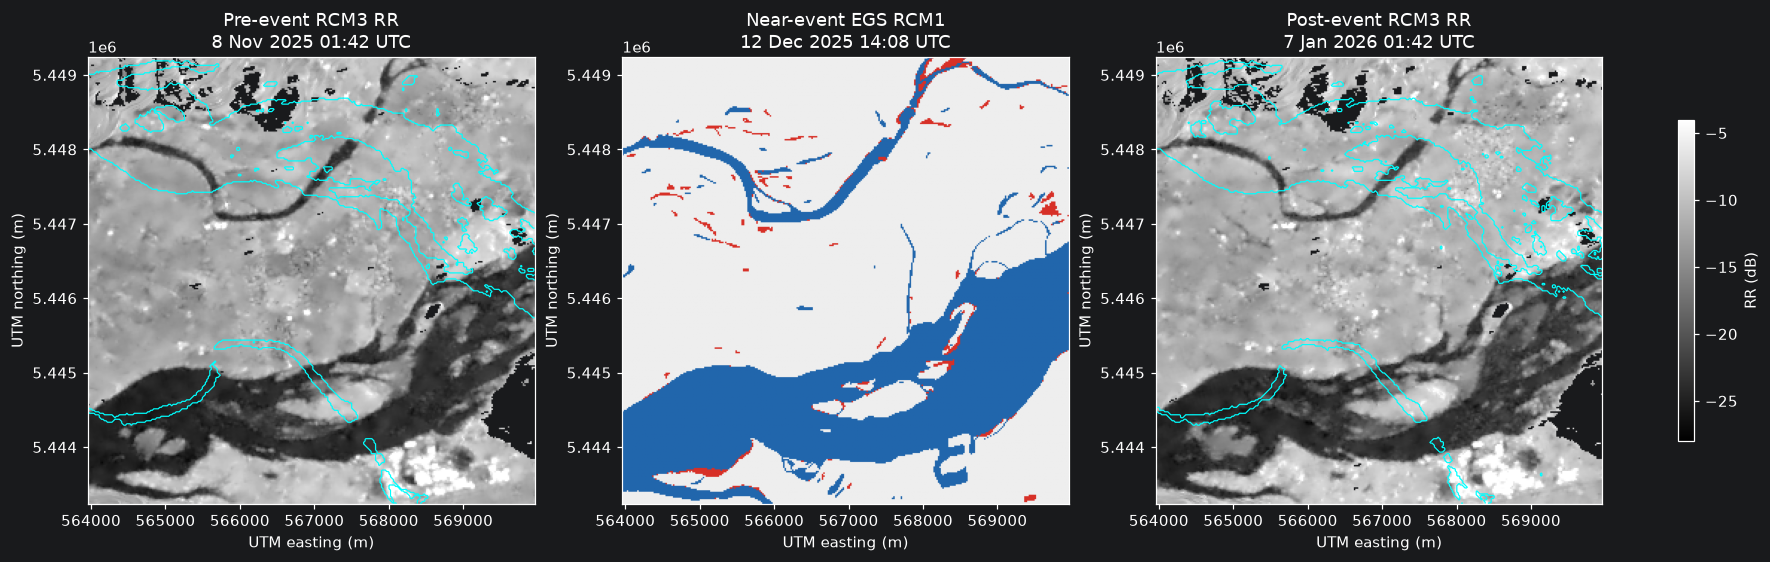

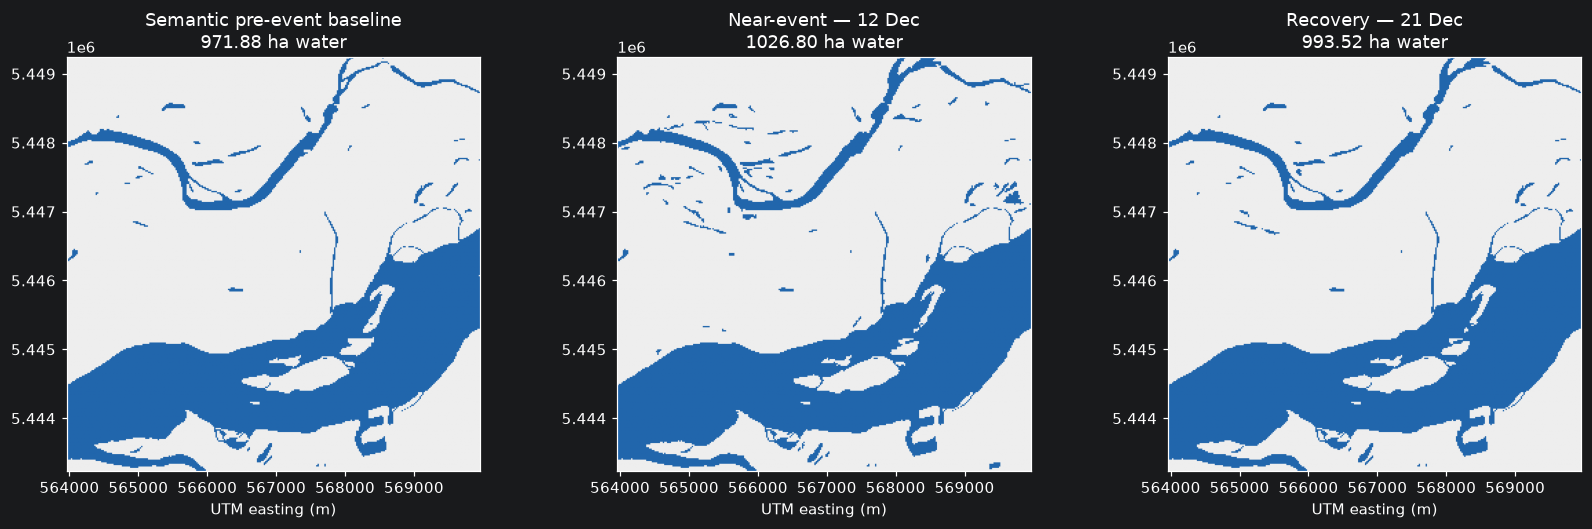

In [35]:
extent = (TARGET_BOUNDS[0], TARGET_BOUNDS[2], TARGET_BOUNDS[1], TARGET_BOUNDS[3])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
pre_rr = np.ma.masked_invalid(ard_scenes["pre-event"]["rr_db"])
post_rr = np.ma.masked_invalid(ard_scenes["post-event"]["rr_db"])
im = axes[0].imshow(pre_rr, cmap="gray", vmin=-28, vmax=-4, extent=extent)
axes[0].contour(ard_scenes["pre-event"]["water"], levels=[0.5], colors="#00ffff", linewidths=0.8, extent=extent)
axes[0].set_title("Pre-event RCM3 RR\n8 Nov 2025 01:42 UTC")
event_class = np.zeros(TARGET_SHAPE, dtype=np.uint8)
event_class[baseline] = 1
event_class[event_gain] = 2
axes[1].imshow(event_class, cmap=ListedColormap(["#eeeeee", "#2166ac", "#d73027"]), vmin=0, vmax=2, extent=extent)
axes[1].set_title("Near-event EGS RCM1\n12 Dec 2025 14:08 UTC")
axes[2].imshow(post_rr, cmap="gray", vmin=-28, vmax=-4, extent=extent)
axes[2].contour(ard_scenes["post-event"]["water"], levels=[0.5], colors="#00ffff", linewidths=0.8, extent=extent)
axes[2].set_title("Post-event RCM3 RR\n7 Jan 2026 01:42 UTC")
for ax in axes:
    ax.set_xlabel("UTM easting (m)")
    ax.set_ylabel("UTM northing (m)")
fig.colorbar(im, ax=[axes[0], axes[2]], shrink=0.72, label="RR (dB)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), constrained_layout=True)
for ax, label, mask in zip(
    axes,
    ["Semantic pre-event baseline", "Near-event — 12 Dec", "Recovery — 21 Dec"],
    [pre_water, event_water, post_water],
):
    shown = np.where(all_egs_valid, mask.astype(float), np.nan)
    ax.imshow(shown, cmap=ListedColormap(["#eeeeee", "#2166ac"]), vmin=0, vmax=1, extent=extent)
    ax.set_title(f"{label}\n{mask.sum()*PIXEL_AREA_HA:.2f} ha water")
    ax.set_xlabel("UTM easting (m)")
plt.show()

## 14. Change-map construction

The comparable EGS semantic series treats class 1 permanent water as the pre-event baseline and class 2 as additional observed flood water. This preserves the EGS product meaning and avoids applying the CEOS-ARD dB threshold to a different representation. The baseline is not presented as a dated pre-event acquisition; the real 8 Nov ARD observation is shown separately above.

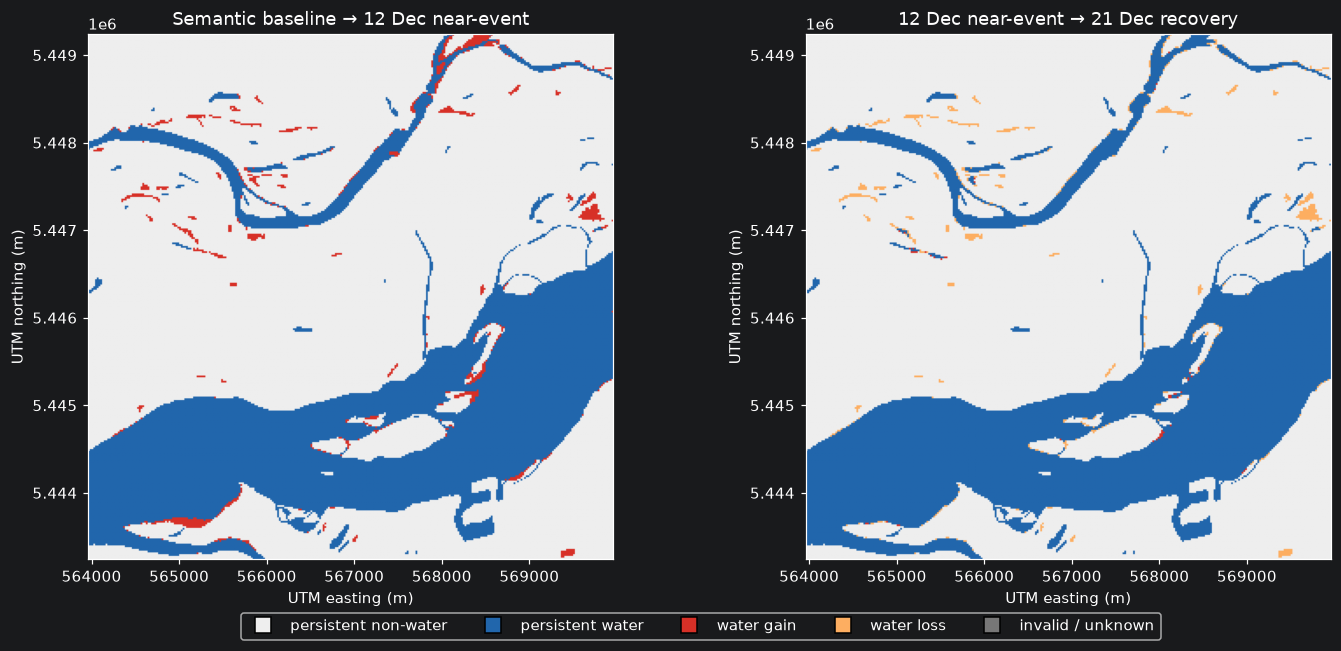

,comparison,water_gain_ha,water_loss_ha
0,baseline → near-event,54.92,0.00
1,near-event → recovery,2.16,35.44


In [36]:
def change_categories(before, after, valid):
    # 0 non-water, 1 persistent water, 2 water gain, 3 water loss, 4 invalid/unknown
    result = np.full(before.shape, 4, dtype=np.uint8)
    result[valid & ~before & ~after] = 0
    result[valid & before & after] = 1
    result[valid & ~before & after] = 2
    result[valid & before & ~after] = 3
    return result

before_event_change = change_categories(pre_water, event_water, all_egs_valid)
event_post_change = change_categories(event_water, post_water, all_egs_valid)
change_cmap = ListedColormap(["#eeeeee", "#2166ac", "#d73027", "#fdae61", "#777777"])
labels = ["persistent non-water", "persistent water", "water gain", "water loss", "invalid / unknown"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
axes[0].imshow(before_event_change, cmap=change_cmap, vmin=0, vmax=4, extent=extent)
axes[0].set_title("Semantic baseline → 12 Dec near-event")
axes[1].imshow(event_post_change, cmap=change_cmap, vmin=0, vmax=4, extent=extent)
axes[1].set_title("12 Dec near-event → 21 Dec recovery")
for ax in axes:
    ax.set(xlabel="UTM easting (m)", ylabel="UTM northing (m)")
handles = [plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=change_cmap(i), markersize=10, label=label)
           for i, label in enumerate(labels)]
fig.legend(handles=handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.06))
plt.show()

change_summary = pd.DataFrame([
    ["baseline → near-event", event_gain.sum()*PIXEL_AREA_HA, 0.0],
    ["near-event → recovery", event_to_post_gain.sum()*PIXEL_AREA_HA, event_to_post_loss.sum()*PIXEL_AREA_HA],
], columns=["comparison", "water_gain_ha", "water_loss_ha"])
display(change_summary.round(2))

## 15. Temporal water-extent analysis

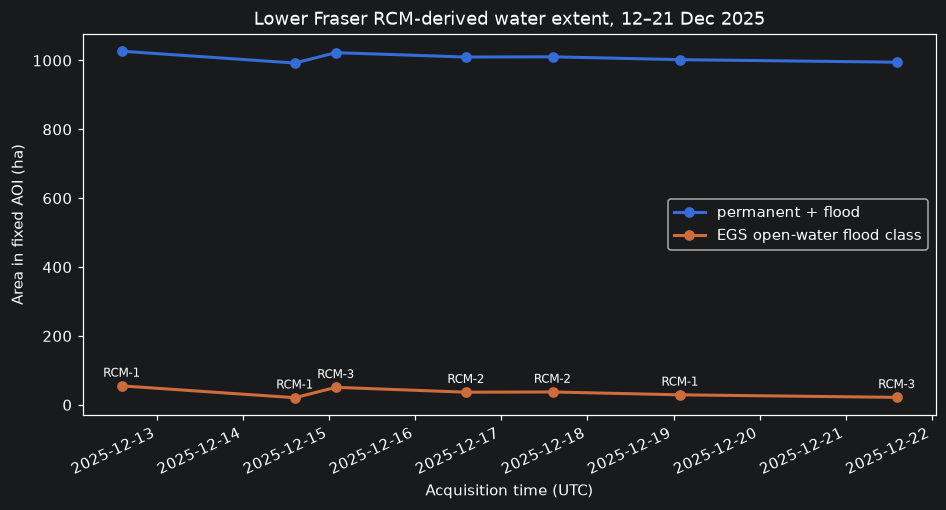

,label,datetime_utc,platform,beam,source_resolution_m,permanent_area_ha,flood_area_ha,total_water_area_ha
0,near-event,2025-12-12 14:08:24+00:00,RCM-1,5M22,5.0,971.88,54.92,1026.80
1,early-recession-1,2025-12-14 14:24:23+00:00,RCM-1,16M9,16.0,971.88,20.60,992.48
2,early-recession-2,2025-12-15 01:50:37+00:00,RCM-3,SC30MB,30.0,971.88,50.72,1022.60
3,mid-recession-1,2025-12-16 14:08:35+00:00,RCM-2,5M22,5.0,973.28,36.60,1009.88
4,mid-recession-2,2025-12-17 14:16:34+00:00,RCM-2,16M16,16.0,973.28,37.28,1010.56
5,late-recession,2025-12-19 01:50:14+00:00,RCM-1,SC30MB,30.0,973.28,28.96,1002.24
6,recovery-period,2025-12-21 14:16:46+00:00,RCM-3,16M16,16.0,973.28,21.64,994.92


In [37]:
egs_df["total_water_area_ha"] = egs_df["permanent_area_ha"] + egs_df["flood_area_ha"]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(egs_df["datetime_utc"], egs_df["total_water_area_ha"], marker="o", linewidth=2, label="permanent + flood")
ax.plot(egs_df["datetime_utc"], egs_df["flood_area_ha"], marker="o", linewidth=2, label="EGS open-water flood class")
for row in egs_df.itertuples():
    ax.annotate(row.platform, (row.datetime_utc, row.flood_area_ha), xytext=(0, 6), textcoords="offset points", ha="center", fontsize=8)
ax.set(title="Lower Fraser RCM-derived water extent, 12–21 Dec 2025",
       xlabel="Acquisition time (UTC)", ylabel="Area in fixed AOI (ha)")
ax.legend()
plt.xticks(rotation=25, ha="right")
plt.show()
display(egs_df[["label", "datetime_utc", "platform", "beam", "source_resolution_m", "permanent_area_ha", "flood_area_ha", "total_water_area_ha"]])

## 16. Grid-based change analysis

The 1 km grid contains 50 × 50 analysis pixels per full cell. It is large enough to damp individual shoreline pixels while remaining interpretable for local exposure screening. Boundary cells are retained with their exact valid denominator. The grid was chosen before viewing change magnitudes.

### Normal versus anomaly

1. **Method/sensor benchmark:** Folly Lake describes observed variability of the validated workflow on a relatively stable control site. Its 5.88% maximum deviation is contextual evidence, not a universal flood threshold or a formal significance test.
2. **Site-specific normal baseline:** normal conditions should preferably come from multiple comparable pre-event observations of this fixed Lower Fraser AOI. The already-discovered data contain only one pre-event RCM-ARD acquisition and one Sentinel-2 observation, and neither is semantically interchangeable with the event-period EGS classes. A defensible multi-date frequency baseline is therefore not available without new discovery/processing. This notebook retains the EGS permanent-water class as a provisional local semantic baseline and labels every 1 km cell as permanent-water, normally dry, or mixed from that binary baseline—without inventing probability cutoffs.
3. **Event anomaly:** the primary anomaly is EGS flood water appearing outside the local permanent-water baseline. Interpretation combines local deviation, spatial concentration/continuity, recession or persistence, independent EO/official agreement, and impact context. A cell being above the Folly Lake contextual value strengthens attention to it but does not by itself establish significance.

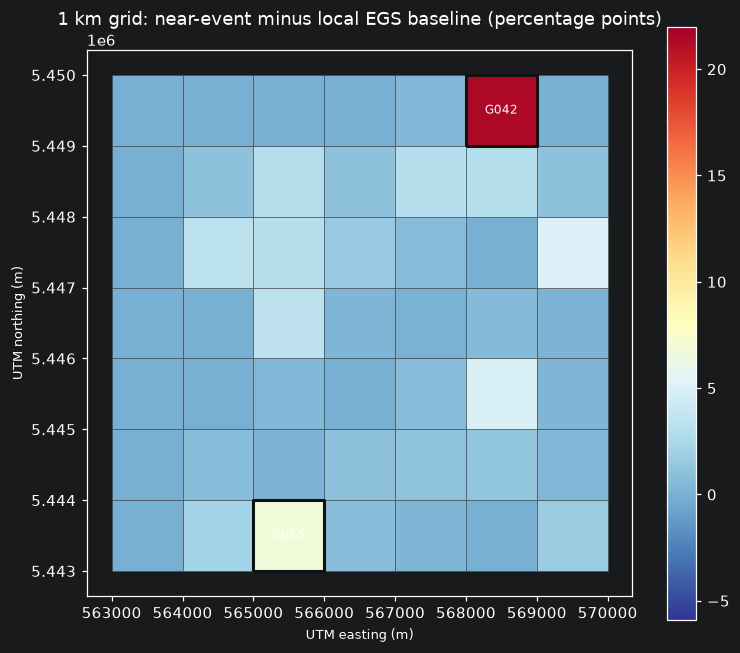

,grid_id,west,south,valid_pixels,valid_pct,pre_water_ratio_pct,event_water_ratio_pct,post_water_ratio_pct,event_minus_pre_pp,post_minus_pre_pp,event_gain_area_ha,event_to_post_loss_ha,above_control_context_5_88pp,baseline_interpretation,anomaly_interpretation,temporal_class
41,G042,568000.0,5449000.0,600,100.0,15.000,36.500,31.833,21.500,16.833,5.16,1.16,True,mixed permanent-water / normally-dry baseline,localized gain above control-site context; corroboration required,recovery observed
14,G015,565000.0,5443000.0,1900,100.0,35.789,42.579,41.684,6.789,5.895,5.16,0.76,True,mixed permanent-water / normally-dry baseline,localized gain above control-site context; corroboration required,recovery observed
46,G047,569000.0,5447000.0,2400,100.0,5.000,10.083,5.000,5.083,0.000,4.88,4.88,False,mixed permanent-water / normally-dry baseline,mapped gain within control-site variation context,recovery observed
37,G038,568000.0,5445000.0,2500,100.0,74.520,79.360,78.560,4.840,4.040,4.84,1.36,False,mixed permanent-water / normally-dry baseline,mapped gain within control-site variation context,recovery observed
17,G018,565000.0,5446000.0,2500,100.0,0.360,3.800,2.080,3.440,1.720,3.44,2.28,False,mixed permanent-water / normally-dry baseline,mapped gain within control-site variation context,recovery observed
11,G012,564000.0,5447000.0,2500,100.0,2.080,5.360,2.080,3.280,0.000,3.28,3.28,False,mixed permanent-water / normally-dry baseline,mapped gain within control-site variation context,recovery observed
18,G019,565000.0,5447000.0,2500,100.0,21.520,24.600,22.200,3.080,0.680,3.08,2.48,False,mixed permanent-water / normally-dry baseline,mapped gain within control-site variation context,recovery observed
19,G020,565000.0,5448000.0,2500,100.0,3.320,6.320,3.320,3.000,0.000,3.00,3.00,False,mixed permanent-water / normally-dry baseline,mapped gain within control-site variation context,recovery observed
40,G041,568000.0,5448000.0,2500,100.0,2.960,5.960,3.440,3.000,0.480,3.00,2.52,False,mixed permanent-water / normally-dry baseline,mapped gain within control-site variation context,recovery observed
33,G034,567000.0,5448000.0,2500,100.0,12.920,15.880,14.800,2.960,1.880,2.96,1.16,False,mixed permanent-water / normally-dry baseline,mapped gain within control-site variation context,recovery observed


In [38]:
left, bottom, right, top = TARGET_BOUNDS
grid_rows = []
grid_id = 0
for x0 in np.arange(np.floor(left / GRID_METRES) * GRID_METRES, right, GRID_METRES):
    for y0 in np.arange(np.floor(bottom / GRID_METRES) * GRID_METRES, top, GRID_METRES):
        cell = box(x0, y0, x0 + GRID_METRES, y0 + GRID_METRES)
        cell_mask = geometry_mask([mapping(cell)], out_shape=TARGET_SHAPE,
                                  transform=TARGET_TRANSFORM, invert=True) & AOI_MASK
        valid = cell_mask & all_egs_valid
        if not valid.any():
            continue
        grid_id += 1
        pre_ratio = pre_water[valid].mean() * 100
        event_ratio = event_water[valid].mean() * 100
        post_ratio = post_water[valid].mean() * 100
        event_change = event_ratio - pre_ratio
        post_change = post_ratio - pre_ratio
        gain_area_ha = (event_gain & cell_mask).sum() * PIXEL_AREA_HA
        loss_to_post_ha = (event_to_post_loss & cell_mask).sum() * PIXEL_AREA_HA
        if np.isclose(pre_ratio, 0.0):
            baseline_interpretation = "normally dry in EGS semantic baseline"
        elif np.isclose(pre_ratio, 100.0):
            baseline_interpretation = "permanent-water EGS semantic baseline"
        else:
            baseline_interpretation = "mixed permanent-water / normally-dry baseline"
        above_control_context = event_change > CONTROL_MAX_DEVIATION_PCT
        if gain_area_ha == 0:
            anomaly_interpretation = "no mapped event water gain"
        elif above_control_context:
            anomaly_interpretation = "localized gain above control-site context; corroboration required"
        else:
            anomaly_interpretation = "mapped gain within control-site variation context"
        if valid.sum() / cell_mask.sum() < 0.8:
            temporal = "unresolved"
        elif gain_area_ha > 0 and post_ratio < event_ratio:
            temporal = "recovery observed"
        elif gain_area_ha > 0 and post_ratio >= event_ratio:
            temporal = "persistent expansion"
        else:
            temporal = "no mapped event gain"
        grid_rows.append({
            "grid_id": f"G{grid_id:03d}", "west": x0, "south": y0,
            "valid_pixels": int(valid.sum()), "valid_pct": 100 * valid.sum() / cell_mask.sum(),
            "pre_water_ratio_pct": pre_ratio, "event_water_ratio_pct": event_ratio,
            "post_water_ratio_pct": post_ratio, "event_minus_pre_pp": event_change,
            "post_minus_pre_pp": post_change,
            "event_gain_area_ha": gain_area_ha,
            "event_to_post_loss_ha": loss_to_post_ha,
            "above_control_context_5_88pp": above_control_context,
            "baseline_interpretation": baseline_interpretation,
            "anomaly_interpretation": anomaly_interpretation,
            "temporal_class": temporal, "geometry": cell,
        })

grid_gdf = gpd.GeoDataFrame(grid_rows, geometry="geometry", crs=WORKING_CRS)
changed_cells = grid_gdf.loc[grid_gdf["above_control_context_5_88pp"]].copy()
fig, ax = plt.subplots(figsize=(8, 7))
grid_gdf.plot(column="event_minus_pre_pp", cmap="RdYlBu_r", vmin=-CONTROL_MAX_DEVIATION_PCT,
              vmax=max(22, grid_gdf.event_minus_pre_pp.max()), legend=True,
              edgecolor="#444", linewidth=0.35, ax=ax)
changed_cells.boundary.plot(color="#111", linewidth=2, ax=ax)
for row in changed_cells.itertuples():
    ax.annotate(row.grid_id, row.geometry.centroid.coords[0], ha="center", va="center", fontsize=8)
ax.set(title="1 km grid: near-event minus local EGS baseline (percentage points)",
       xlabel="UTM easting (m)", ylabel="UTM northing (m)")
plt.show()

grid_stats = grid_gdf.drop(columns="geometry").sort_values("event_minus_pre_pp", ascending=False)
display(grid_stats.round(3))

## 17. Measurement-noise comparison

In [39]:
pre_area = pre_water.sum() * PIXEL_AREA_HA
event_area = event_water.sum() * PIXEL_AREA_HA
post_area = post_water.sum() * PIXEL_AREA_HA
event_gain_ha = event_gain.sum() * PIXEL_AREA_HA
relative_gain_pct = 100 * event_gain_ha / pre_area
control_median_ha = 70.76
control_max_abs_ha = control_median_ha * CONTROL_MAX_DEVIATION_PCT / 100

noise_table = pd.DataFrame([
    ["Folly Lake coefficient of variation", CONTROL_CV_PCT, "Empirical descriptive context only"],
    ["Folly Lake largest single-date deviation", CONTROL_MAX_DEVIATION_PCT, f"≈ {control_max_abs_ha:.2f} ha at the 70.76 ha median"],
    ["Folly Lake same-day RCM/S2 area difference", CONTROL_S2_AREA_DIFFERENCE_PCT, "Cross-sensor area benchmark"],
    ["Event AOI total relative water gain", relative_gain_pct, f"{event_gain_ha:.2f} ha; {event_gain_ha/control_max_abs_ha:.1f}× the control absolute deviation"],
    ["Largest local 1 km-grid increase", grid_gdf.event_minus_pre_pp.max(), "Local percentage-point signal"],
], columns=["measure", "percent / percentage points", "interpretation"])
display(noise_table.round(3))
print(f"Cells above the 5.88 pp control-site context: {len(changed_cells)} / {len(grid_gdf)}; gain inside them: {changed_cells.event_gain_area_ha.sum():.2f} ha")
print("Conclusion: these are contextual comparisons, not a universal threshold or a formal significance test. The local anomaly interpretation also requires spatial, temporal, independent-source, and impact evidence.")

,measure,percent / percentage points,interpretation
0,Folly Lake coefficient of variation,3.200,Empirical descriptive context only
1,Folly Lake largest single-date deviation,5.880,≈ 4.16 ha at the 70.76 ha median
2,Folly Lake same-day RCM/S2 area difference,4.880,Cross-sensor area benchmark
3,Event AOI total relative water gain,5.651,54.92 ha; 13.2× the control absolute deviation
4,Largest local 1 km-grid increase,21.500,Local percentage-point signal


Cells above the 5.88 pp control-site context: 2 / 49; gain inside them: 10.32 ha
Conclusion: these are contextual comparisons, not a universal threshold or a formal significance test. The local anomaly interpretation also requires spatial, temporal, independent-source, and impact evidence.


## 18. Multi-source agreement

,comparison,valid_pixels,TP,FP,FN,TN,precision,recall,F1,IoU,RCM_area_ha,S2_area_ha,area_difference_ha
0,RCM 21 Dec recovery water vs S2 27 Dec NDWI,88515,15774,8017,357,64367,0.663,0.978,0.79,0.653,951.64,645.24,306.4


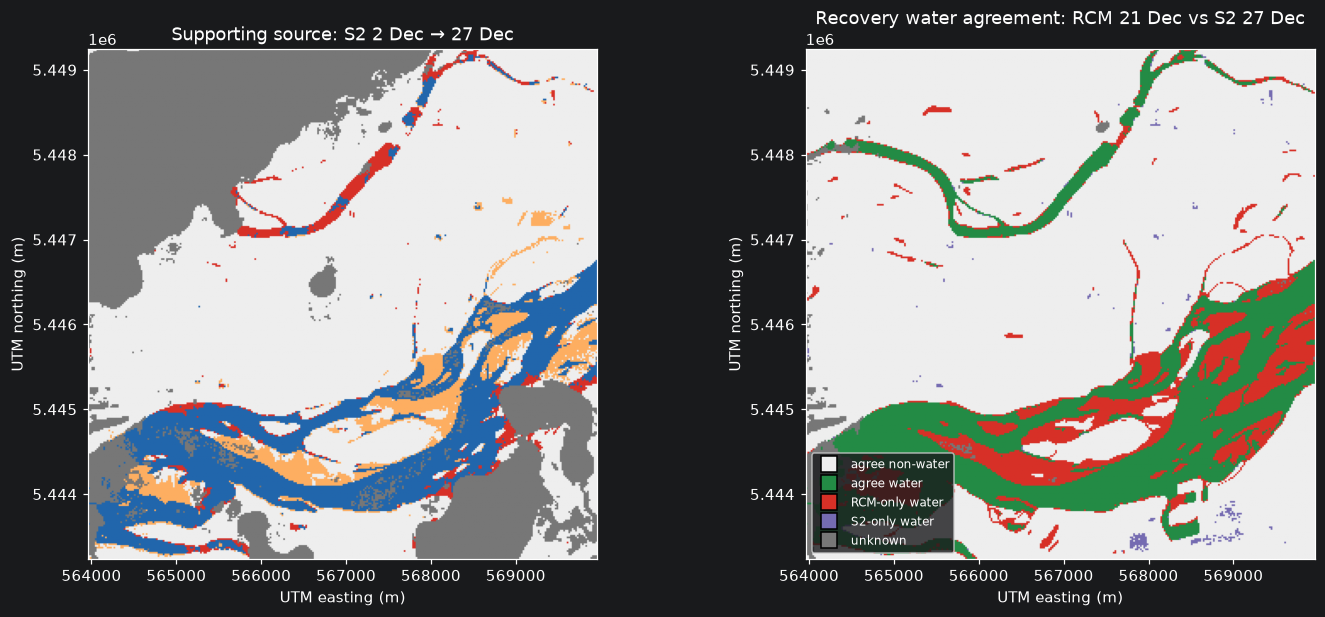

Likely disagreement drivers: 6.2-day timing offset, water recession, optical/SAR physics, cloud/SCL masking, resolution, and mixed shoreline pixels.


In [41]:
def agreement_metrics(prediction, reference, valid, label):
    pred = prediction[valid].astype(bool)
    ref = reference[valid].astype(bool)
    tp = int(np.sum(pred & ref)); fp = int(np.sum(pred & ~ref))
    fn = int(np.sum(~pred & ref)); tn = int(np.sum(~pred & ~ref))
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = tp / (tp + fn) if tp + fn else np.nan
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else np.nan
    iou = tp / (tp + fp + fn) if tp + fp + fn else np.nan
    return {
        "comparison": label, "valid_pixels": int(valid.sum()), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": precision, "recall": recall, "F1": f1, "IoU": iou,
        "RCM_area_ha": pred.sum() * PIXEL_AREA_HA, "S2_area_ha": ref.sum() * PIXEL_AREA_HA,
        "area_difference_ha": (pred.sum() - ref.sum()) * PIXEL_AREA_HA,
    }

recovery_common = all_egs_valid & s2_scenes["recovery-period"]["valid"]
agreement = agreement_metrics(post_water, s2_scenes["recovery-period"]["water"], recovery_common,
                              "RCM 21 Dec recovery water vs S2 27 Dec NDWI")
display(pd.DataFrame([agreement]).round(3))

# 0 both non-water, 1 agree water, 2 RCM-only, 3 S2-only, 4 unknown
agreement_map = np.full(TARGET_SHAPE, 4, dtype=np.uint8)
agreement_map[recovery_common & ~post_water & ~s2_scenes["recovery-period"]["water"]] = 0
agreement_map[recovery_common & post_water & s2_scenes["recovery-period"]["water"]] = 1
agreement_map[recovery_common & post_water & ~s2_scenes["recovery-period"]["water"]] = 2
agreement_map[recovery_common & ~post_water & s2_scenes["recovery-period"]["water"]] = 3
agreement_cmap = ListedColormap(["#eeeeee", "#238b45", "#d73027", "#756bb1", "#777777"])
agreement_labels = ["agree non-water", "agree water", "RCM-only water", "S2-only water", "unknown"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
s2_change = change_categories(s2_scenes["pre-event"]["water"], s2_scenes["recovery-period"]["water"], s2_common)
axes[0].imshow(s2_change, cmap=change_cmap, vmin=0, vmax=4, extent=extent)
axes[0].set_title("Supporting source: S2 2 Dec → 27 Dec")
axes[1].imshow(agreement_map, cmap=agreement_cmap, vmin=0, vmax=4, extent=extent)
axes[1].set_title("Recovery water agreement: RCM 21 Dec vs S2 27 Dec")
for ax in axes:
    ax.set(xlabel="UTM easting (m)", ylabel="UTM northing (m)")
handles = [plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=agreement_cmap(i), markersize=10, label=label)
           for i, label in enumerate(agreement_labels)]
axes[1].legend(handles=handles, loc="lower left", fontsize=8)
plt.show()

print("Likely disagreement drivers: 6.2-day timing offset, water recession, optical/SAR physics, cloud/SCL masking, resolution, and mixed shoreline pixels.")

## 19. Event classification: transient / persistent / recovery

In [42]:
temporal_counts = grid_gdf["temporal_class"].value_counts().rename_axis("temporal_class").reset_index(name="grid_cells")
display(temporal_counts)
decline_pct = 100 * (egs_df.iloc[0].flood_area_ha - egs_df.iloc[-1].flood_area_ha) / egs_df.iloc[0].flood_area_ha
print(f"EGS open-water flood class declined from {egs_df.iloc[0].flood_area_ha:.2f} ha to {egs_df.iloc[-1].flood_area_ha:.2f} ha ({decline_pct:.1f}% decline).")
display(Markdown("**Event-level classification: recovering flood, with localized residual/persistent expansion.** This is a short-term event trajectory, not a long-term environmental trend."))

,temporal_class,grid_cells
0,recovery observed,32
1,no mapped event gain,16
2,persistent expansion,1


EGS open-water flood class declined from 54.92 ha to 21.64 ha (60.6% decline).


**Event-level classification: recovering flood, with localized residual/persistent expansion.** This is a short-term event trajectory, not a long-term environmental trend.

## 20. Initial impact-overlay analysis

Road geometry is fetched from the OpenStreetMap Overpass API and intersected with the near-event water-gain raster polygon. Results describe geometric **intersection / potential exposure only**. They do not prove closure, damage, traffic impact, or flood depth. Wider official reports (including Highway 1 impacts) provide event context but are not assigned to this compact AOI unless the geometries intersect it.

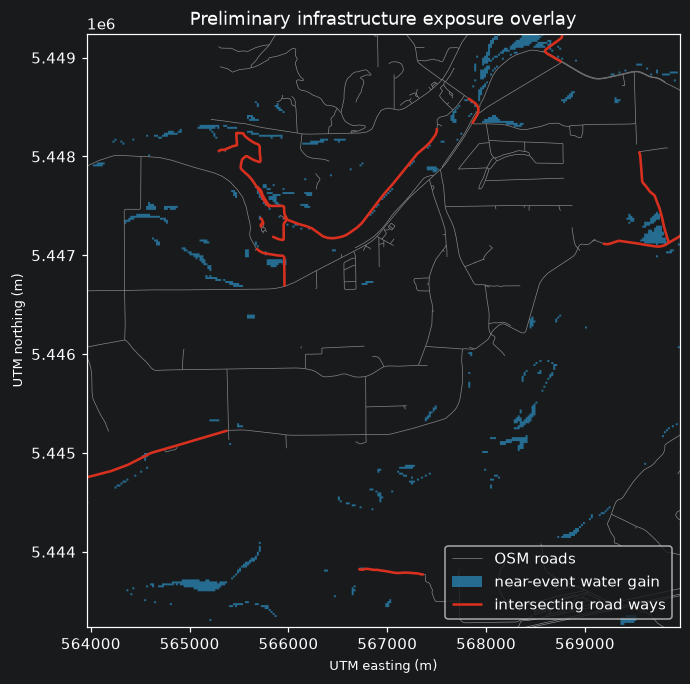

,OSM_road_ways_in_AOI,ways_intersecting_water_gain,intersection_length_km,bridge_ways_intersecting,bridge_intersection_length_m,Highway_1_ways_intersecting_in_AOI
0,238,14,0.346,1,8.717,0


,osm_id,highway,name,ref,bridge,flood_intersection_m
106,576124615,track,Nicomen Island Dyke,NaN,NaN,76.77
74,35501431,track,Dyke Road,NaN,NaN,47.15
41,35499368,residential,Ross Road,NaN,NaN,40.00
183,1416643899,track,NaN,NaN,NaN,40.00
180,1394094237,path,NaN,NaN,NaN,36.43
98,502175282,primary,Lougheed Highway,BC 7,NaN,32.62
46,35499471,residential,Nicomen Slough Road,NaN,NaN,20.38
129,1346293505,track,NaN,NaN,NaN,14.74
165,1353553405,track,NaN,NaN,NaN,13.06
85,62001004,primary,Lougheed Highway,BC 7,yes,8.72


In [43]:
def overpass_roads(bbox):
    west, south, east, north = bbox
    query = f'[out:json][timeout:90];way["highway"]({south},{west},{north},{east});out tags geom;'
    payload = None
    for endpoint in [
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
        "https://overpass.private.coffee/api/interpreter",
    ]:
        try:
            request = Request(endpoint + "?" + urlencode({"data": query}),
                              headers={"User-Agent": "earth-in-motion-hackathon/1.0"})
            with urlopen(request, timeout=75) as response:
                payload = json.load(response)
            break
        except Exception as exc:
            print("Overpass endpoint failed:", endpoint, type(exc).__name__)
    if payload is None:
        raise RuntimeError("No Overpass endpoint returned road data")
    records = []
    for element in payload.get("elements", []):
        coords = [(node["lon"], node["lat"]) for node in element.get("geometry", [])]
        if len(coords) < 2:
            continue
        tags = element.get("tags", {})
        records.append({
            "osm_id": element["id"], "highway": tags.get("highway"), "name": tags.get("name"),
            "ref": tags.get("ref"), "bridge": tags.get("bridge"), "geometry": LineString(coords),
        })
    return gpd.GeoDataFrame(records, geometry="geometry", crs=4326)

gain_geometries = [shape(geom) for geom, value in shapes(
    event_gain.astype(np.uint8), mask=event_gain, transform=TARGET_TRANSFORM) if value == 1]
gain_geometry = unary_union(gain_geometries)
roads = overpass_roads(AOI_BBOX).to_crs(WORKING_CRS)
roads["flood_intersection_m"] = roads.geometry.intersection(gain_geometry).length
potentially_exposed = roads.loc[roads["flood_intersection_m"] > 0].copy()
bridges = potentially_exposed.loc[
    potentially_exposed["bridge"].notna() & ~potentially_exposed["bridge"].isin(["no", "false"])]
highway1 = potentially_exposed.loc[
    potentially_exposed["ref"].fillna("").str.contains(r"(?:^|;)1(?:$|;)", regex=True)]

fig, ax = plt.subplots(figsize=(8, 7))
roads.plot(ax=ax, color="#888", linewidth=0.45, label="OSM roads")
gpd.GeoSeries([gain_geometry], crs=WORKING_CRS).plot(ax=ax, color="#2b8cbe", alpha=0.72, label="near-event water gain")
potentially_exposed.plot(ax=ax, color="#d7301f", linewidth=1.7, label="intersecting road ways")
ax.set(xlim=(left, right), ylim=(bottom, top), title="Preliminary infrastructure exposure overlay",
       xlabel="UTM easting (m)", ylabel="UTM northing (m)")
ax.legend(loc="lower right")
plt.show()

impact_summary = pd.DataFrame([{
    "OSM_road_ways_in_AOI": len(roads),
    "ways_intersecting_water_gain": len(potentially_exposed),
    "intersection_length_km": potentially_exposed.flood_intersection_m.sum() / 1000,
    "bridge_ways_intersecting": len(bridges),
    "bridge_intersection_length_m": bridges.flood_intersection_m.sum(),
    "Highway_1_ways_intersecting_in_AOI": len(highway1),
}])
display(impact_summary.round(3))
display(potentially_exposed[["osm_id", "highway", "name", "ref", "bridge", "flood_intersection_m"]]
        .sort_values("flood_intersection_m", ascending=False).round(2))

## 21. Findings

In [44]:
findings = f'''
### Evidence-backed findings

1. The selected RCM-derived event sequence has **{all_egs_valid.mean()*100:.1f}% common valid coverage** on the fixed 20 m grid.
2. Comparable semantic water area increased from **{pre_area:.2f} ha** to **{event_area:.2f} ha** on 12 Dec (gain **{event_gain_ha:.2f} ha**), then fell to **{post_area:.2f} ha** by 21 Dec.
3. **{len(changed_cells)} of {len(grid_gdf)}** 1 km cells are above the Folly Lake 5.88 percentage-point contextual value; their mapped event gain totals **{changed_cells.event_gain_area_ha.sum():.2f} ha**. This flag is not a universal significance decision.
4. Recovery-period RCM/Sentinel-2 agreement is **IoU {agreement['IoU']:.3f}, F1 {agreement['F1']:.3f}** on {agreement['valid_pixels']:,} mutually valid pixels.
5. The mapped event gain intersects **{len(potentially_exposed)} OSM road ways** over **{potentially_exposed.flood_intersection_m.sum()/1000:.3f} km**, including **{len(bridges)} bridge-tagged way**. These are potentially exposed features, not confirmed damage.
6. The trajectory is best described as **recovering, with localized residual/persistent expansion**, not as a long-term trend.
'''
display(Markdown(findings))


### Evidence-backed findings

1. The selected RCM-derived event sequence has **100.0% common valid coverage** on the fixed 20 m grid.
2. Comparable semantic water area increased from **971.88 ha** to **1026.80 ha** on 12 Dec (gain **54.92 ha**), then fell to **993.52 ha** by 21 Dec.
3. **2 of 49** 1 km cells are above the Folly Lake 5.88 percentage-point contextual value; their mapped event gain totals **10.32 ha**. This flag is not a universal significance decision.
4. Recovery-period RCM/Sentinel-2 agreement is **IoU 0.653, F1 0.790** on 88,515 mutually valid pixels.
5. The mapped event gain intersects **14 OSM road ways** over **0.346 km**, including **1 bridge-tagged way**. These are potentially exposed features, not confirmed damage.
6. The trajectory is best described as **recovering, with localized residual/persistent expansion**, not as a long-term trend.


## 22. Limitations

- EGS products report **Moderate** confidence and use mixed source resolutions (5, 16, and 30 m) and viewing geometries; rasterization to 20 m standardizes comparison but does not erase source-scale effects.
- A defensible multi-date, site-specific pre-event water-frequency baseline was not feasible from the already-discovered data. Only one pre-event RCM-ARD acquisition and one Sentinel-2 observation were available, and neither is semantically interchangeable with EGS. The comparable “pre” mask therefore remains the EGS permanent-water class embedded in the first event product, not a dated pre-event EGS acquisition. The real 8 Nov RCM-ARD observation is shown separately.
- The fixed Phase 3 RR threshold is conditional on the CEOS-ARD representation and seeded-component rule; it is not calibrated for RCM Level-1 or EGS classes.
- The first EGS acquisition is 12 Dec, after the initial 10 Dec warning, so it is labelled **near-event**, not flood peak.
- Sentinel-2 event-window scenes were cloud-obstructed. The independent quantitative check is recovery-period (21 Dec RCM vs 27 Dec optical), with a 6.2-day offset. The 2 Dec optical image also has substantial scene/AOI cloud masking.
- Cross-source disagreement can reflect timing, recession, sensor physics, SCL masking, resolution, mixed pixels, vegetation, and SAR roughness.
- The Folly Lake 3.20%, 5.88%, and 4.88% values describe method variability at a different control landscape. They are contextual checks—not formal significance thresholds, universal flood cutoffs, or substitutes for a Lower Fraser baseline.
- OSM completeness and tagging vary. Intersection indicates potential exposure only and cannot establish physical damage.
- Official reports validate event context at regional scale, not individual pixels. No causal climate attribution is made.

## 23. Recommendation for Phase 5

Proceed with this case for Phase 5 because the event has a documented public-safety context, seven usable RCM-derived event observations, actual RCM pre/post brackets, a coherent mapped water-gain signal, two locally benchmark-exceeding grid cells, independent optical recovery agreement, and a preliminary infrastructure intersection. Phase 5 should focus on the two changed grid cells and their road/bridge context, preserve confidence/uncertainty language, and avoid presenting regional official damage reports as pixel-level validation.

Before productization, cache small derived outputs (not raw scenes), add provenance fields for every displayed metric, and design the dashboard so the user can distinguish semantic EGS water, CEOS-ARD threshold water, independent optical agreement, and unknown pixels.